In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [51]:
# Build the dataset
block_size = 3  # context length: how many characters do we take to predict the next one
X, Y = [], []

for w in words:
    context = [0] * block_size  # initialize context with 'block_size' number of '.'
    for ch in w + '.':  # we add '.' to the end to signify end of word
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]  # crop the first and append to last to keep the context size fixed

X = torch.tensor(X)
Y = torch.tensor(Y)

In [5]:

X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [6]:
# Trying to create a embedding model for given words into a dimension of 30 | Paper
# here we are trying to create embedding for each character in the dimension of 2
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

### Idea of the Architecture

- We want to move away from context window of size = 1 to n
- for the we provide historical context in form of indexes of words in this case characters
- One idea is to move forward with OHE vectors and then try to optimise the weight matrix but it provides a problem that in some cases OOV problem occurs hence we cant OHE and no further process can happen!!
- So, here we propose idea of embeddings for a given character/ word such that characters/ words that occur in similar context tend to be closer in the vector space!!

How?
- So we start with index of the previous context window
- Convert those to OHE (n x vocab_size(eg 27 for characters))
- Then provide a lookup table (vocab_size x embedding_dimension)
- so each index will be represented by vector of size of embedding_dimension
- which can be attained by multiplyiing OHE x Loopup table matrix multiplication
- or directly indexing on the row from lookup table

What else?
- Further, we can decide on number of neurons in the next layer
- This layer will be Fully Connected layer -> tanh -> fully connected output layer (output size = vocab_size) -> softmax
- Then we go ahead and check for CCE; L = sum of - (y * log(p)) over ground truth classes and try to optimise trainable parameters!!

In [8]:
C = torch.randn((27, 2))  # character embeddings
# Now need to convert inputs ids to OHE
C[5]


tensor([-0.4142, -0.5652])

In [12]:
C.dtype

torch.float32

In [15]:
# OHE x Lookup table === First layer of the embedding model
# Linear layer with OHE input is equivalent to a lookup table for that index
# We can just use loop up table instead

matrix_multiplication = F.one_hot(X, num_classes=27).float() @ C  # (N, block_size, 27) @ (27, 2) --> (N, block_size, 2)

C[[4, 5, 6]]

tensor([[ 0.4303,  0.4690],
        [-0.4142, -0.5652],
        [-0.9154,  1.1928]])

In [16]:
# can do this directly using indexing
C[X].shape

torch.Size([32, 3, 2])

In [ ]:
# Lets construct the full model now
embedding_dim = 2
hidden_layer_nodes = 100
W1 = torch.randn((block_size * embedding_dim, hidden_layer_nodes))  # first layer weights
b1 = torch.randn(hidden_layer_nodes)  # first layer bias
emb = C[X]  # lookup table


RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [20]:
print(emb.shape, W1.shape)
emb @ W1 + b1  # linear layer operation

torch.Size([32, 3, 2]) torch.Size([6, 100])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [19]:
emb.shape # need to reshape it before passing to linear layer
emb.reshape(-1, block_size * embedding_dim) @ W1 + b1  # linear layer operation

tensor([[-3.3828,  4.6943, -8.5849,  ..., -8.4682, 10.9243, -2.0572],
        [-1.3409,  0.4152, -6.5964,  ..., -3.0426, 10.3459, -1.6299],
        [ 2.2680, -3.6683, -6.7511,  ...,  1.3251,  6.6736,  0.6187],
        ...,
        [-0.0881,  3.4956, -1.3422,  ..., -3.1852,  3.0994, -2.9365],
        [-4.7658,  0.1923, -4.3171,  ..., -2.9893,  3.2845, -3.6636],
        [-2.4986,  4.1443, -4.1850,  ..., -2.9101,  1.5399, -3.8776]])

In [23]:
# Playing out with dimensions
a = torch.arange(18)
print(a.shape)
a

torch.Size([18])


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [24]:
a.view(6, 3)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])

In [ ]:
a.view(3, 2, 3) # Super efficient no extra memory used

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]]])

In [26]:
emb.shape

torch.Size([32, 3, 2])

In [27]:
emb.view(-1, block_size * embedding_dim).shape

torch.Size([32, 6])

In [28]:
emb.view(-1, block_size * embedding_dim)

tensor([[ 1.2129, -2.2960,  1.2129, -2.2960,  1.2129, -2.2960],
        [ 1.2129, -2.2960,  1.2129, -2.2960, -0.4142, -0.5652],
        [ 1.2129, -2.2960, -0.4142, -0.5652, -0.9688, -0.4621],
        [-0.4142, -0.5652, -0.9688, -0.4621, -0.9688, -0.4621],
        [-0.9688, -0.4621, -0.9688, -0.4621,  1.2986,  0.0373],
        [ 1.2129, -2.2960,  1.2129, -2.2960,  1.2129, -2.2960],
        [ 1.2129, -2.2960,  1.2129, -2.2960,  0.0200, -0.3251],
        [ 1.2129, -2.2960,  0.0200, -0.3251,  2.0182, -0.0184],
        [ 0.0200, -0.3251,  2.0182, -0.0184,  1.5063,  0.2277],
        [ 2.0182, -0.0184,  1.5063,  0.2277,  1.9590,  0.6314],
        [ 1.5063,  0.2277,  1.9590,  0.6314,  1.5063,  0.2277],
        [ 1.9590,  0.6314,  1.5063,  0.2277,  1.2986,  0.0373],
        [ 1.2129, -2.2960,  1.2129, -2.2960,  1.2129, -2.2960],
        [ 1.2129, -2.2960,  1.2129, -2.2960,  1.2986,  0.0373],
        [ 1.2129, -2.2960,  1.2986,  0.0373,  1.9590,  0.6314],
        [ 1.2986,  0.0373,  1.9590,  0.6

In [39]:
from torch import softmax


h = emb.view(-1, block_size * embedding_dim) @ W1 + b1  # linear layer operation
h_act = h.tanh()

# Broadcasting of b
print((emb.view(-1, block_size * embedding_dim) @ W1).shape)
print(b1.shape)
# n x 100
# 100

#  1, 100 # same bias added to all rows

# Output layer
W2 = torch.randn(100, 27)
b2 = torch.randn(27)
logits = h_act @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([32, 100])
torch.Size([100])


torch.Size([32, 27])

In [41]:
# Creating CCE
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(11.1772)

### Respectable code

In [62]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((block_size * embedding_dim, hidden_layer_nodes), generator=g)  # first layer weights
b1 = torch.randn(hidden_layer_nodes, generator=g)  # first layer bias
W2 = torch.randn((hidden_layer_nodes, vocab_size), generator=g)  # first layer weights
b2 = torch.randn(vocab_size, generator=g)  # first layer bias
parameters = [C, W1, b1, W2, b2]

In [63]:
sum(p.nelement() for p in parameters)

3481

In [54]:
emb = C[X]
h = emb.view(-1, block_size * embedding_dim) @ W1 + b1
h = h.tanh()
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
# Batch Gradient Descent
for p in parameters:
    p.requires_grad = True

for _ in range(100):
    # forward pass
    emb = C[X]
    h = emb.view(-1, block_size * embedding_dim) @ W1 + b1
    h = h.tanh()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print("Loss: ", loss.item())
    # much more mathematically better
    # manages inf possibility of .exp()

    # Backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

Loss:  19.505229949951172
Loss:  17.08448600769043
Loss:  15.776531219482422
Loss:  14.833338737487793
Loss:  14.002596855163574
Loss:  13.253254890441895
Loss:  12.579915046691895
Loss:  11.983097076416016
Loss:  11.470491409301758
Loss:  11.05185604095459
Loss:  10.709586143493652
Loss:  10.407632827758789
Loss:  10.127808570861816
Loss:  9.86436653137207
Loss:  9.614505767822266
Loss:  9.37644100189209
Loss:  9.148946762084961
Loss:  8.931114196777344
Loss:  8.722233772277832
Loss:  8.521753311157227
Loss:  8.329231262207031
Loss:  8.144330024719238
Loss:  7.966795921325684
Loss:  7.796455383300781
Loss:  7.633191108703613
Loss:  7.476912975311279
Loss:  7.327527046203613
Loss:  7.184890270233154
Loss:  7.048797130584717
Loss:  6.9189581871032715
Loss:  6.795024394989014
Loss:  6.676610469818115
Loss:  6.563325881958008
Loss:  6.454796314239502
Loss:  6.350675582885742
Loss:  6.250650405883789
Loss:  6.1544389724731445
Loss:  6.061791896820068
Loss:  5.9724884033203125
Loss:  5.8863

In [ ]:
logits.max(1) # argmax()

torch.return_types.max(
values=tensor([11.3379, 13.0894, 18.9434, 17.5786, 12.7205, 11.3379, 13.0234, 11.5993,
        13.5442, 15.5540, 12.5548, 17.6663, 11.3379, 12.6919, 13.9530, 17.0410,
        11.3379, 13.8052, 11.4075, 13.1371, 15.8441, 12.1391,  7.9167,  7.8798,
        13.8772, 11.3379, 13.0983, 13.6820, 11.2885, 14.2338, 15.6165, 12.0455],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))

In [50]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [64]:
# Mini Batch Gradient Descent with Learning rate decay
lrs = torch.linspace(-3, 0, 1000)
lrs = 10**lrs
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True

for i in range(1000):
    ix = torch.randint(0, X.shape[0], (32, )) # batch size 
    # forward pass
    emb = C[X[ix]]
    h = emb.view(-1, block_size * embedding_dim) @ W1 + b1
    h = h.tanh()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print("Loss: ", loss.item())
    # much more mathematically better
    # manages inf possibility of .exp()

    # Backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # Update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    lri.append(lr)
    lossi.append(loss.item())
print(loss.item())

Loss:  19.652114868164062
Loss:  18.843048095703125
Loss:  20.844890594482422
Loss:  17.93988800048828
Loss:  19.25107765197754
Loss:  19.370986938476562
Loss:  20.049884796142578
Loss:  18.619651794433594
Loss:  17.63927459716797
Loss:  19.139583587646484
Loss:  20.792089462280273
Loss:  17.67609977722168
Loss:  18.573305130004883
Loss:  21.322399139404297
Loss:  17.53451919555664
Loss:  17.828813552856445
Loss:  19.856857299804688
Loss:  15.82160472869873
Loss:  18.17475128173828
Loss:  20.87483024597168
Loss:  18.434432983398438
Loss:  16.70631980895996
Loss:  18.461429595947266
Loss:  15.700738906860352
Loss:  21.753366470336914
Loss:  19.929378509521484
Loss:  20.32872772216797
Loss:  18.780250549316406
Loss:  18.489700317382812
Loss:  17.628520965576172
Loss:  19.67807388305664
Loss:  16.397321701049805
Loss:  22.155784606933594
Loss:  19.783384323120117
Loss:  16.507083892822266
Loss:  19.811450958251953
Loss:  18.548023223876953
Loss:  16.39016342163086
Loss:  16.42988777160644

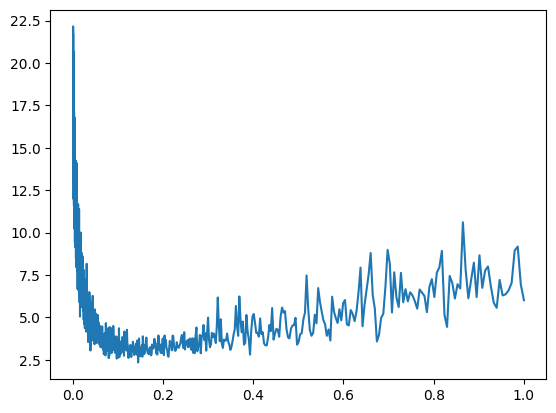

In [65]:
plt.plot(lri, lossi)

In [ ]:
#  find decent learning rate and then train few steps and later do learning rate decay

### Splitting train - val - test dataset | 80% - 10% - 10%

- Can do a lot of variation in the architecture of the neural network

In [69]:
# Building train - test split

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words=words[:n1])
Xdev, Ydev = build_dataset(words=words[n1:n2])
Xte, Yte = build_dataset(words=words[n2:])

- Training

In [116]:
g = torch.Generator().manual_seed(2147483647)
hidden_layer_nodes = 200
embedding_dim = 10
vocab_size = 27
C = torch.randn((vocab_size, embedding_dim), generator=g)
W1 = torch.randn((block_size * embedding_dim, hidden_layer_nodes), generator=g)  # first layer weights
b1 = torch.randn(hidden_layer_nodes, generator=g)  # first layer bias
W2 = torch.randn((hidden_layer_nodes, vocab_size), generator=g)  # first layer weights
b2 = torch.randn(vocab_size, generator=g)  # first layer bias
parameters = [C, W1, b1, W2, b2]

In [117]:
# Mini Batch Gradient Descent with Learning rate decay
lrs = torch.linspace(-3, 0, 1000)
lrs = 10**lrs
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True

for i in range(200000):
    ix = torch.randint(0, Xtr.shape[0], (32, )) # batch size 
    # forward pass
    emb = C[Xtr[ix]]
    h = emb.view(-1, block_size * embedding_dim) @ W1 + b1
    h = h.tanh()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print("Loss: ", loss.item())
    # much more mathematically better
    # manages inf possibility of .exp()

    # Backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # Update
    # lr = lrs[i]
    lr = 0.1 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lr)
    # lossi.append(loss.item())
print(loss.item())

1.9277175664901733


### Evaluation

In [118]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size*embedding_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1761, grad_fn=<NllLossBackward0>)

In [119]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, block_size*embedding_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1666, grad_fn=<NllLossBackward0>)

In [120]:
# Underfitting -> Shallo NN
# lets make it more deeper!!

# Increased nodes but still not as progressive -> embedding are not that informative

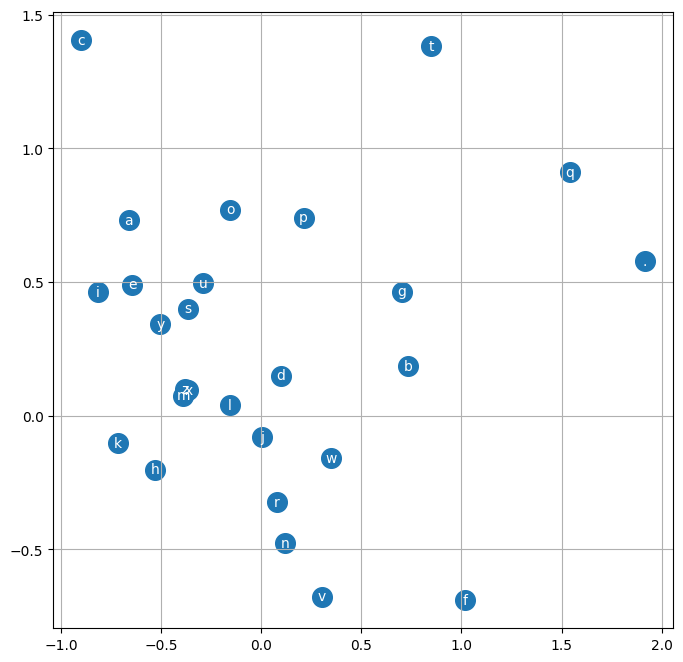

In [121]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)

for i in range(C.shape[0]):
    plt.text(C[i, 0].item(),
             C[i, 1].item(),
             itos[i],
             ha='center',
             va='center',
             color='white')
plt.grid('minor')

In [122]:
# Sample from the model

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix==0:
            break
    print(''.join(itos[i] for i in out))

sir.
gialynn.
tea.
gize.
melup.
zszon.
shillani.
lege.
malaser.
leig.
zoustanr.
caths.
mari.
salen.
nix.
faitee.
amarquarabigotivisherlyn.
tofathan.
thuz.
oola.
